📦 Step 1: Libraries imported successfully.

📊 Step 2: Dataset loaded successfully from '/Heart_Disease_Prediction.csv'.
Dataset Dimensions: 270 rows, 14 columns.
🎯 Identified target classification column: 'Heart Disease'
🔄 Text labels detected in 'Heart Disease'. Standardizing to numeric binary format (0 and 1)...
✅ No missing values detected. Dataset is clean.

📋 Feature Summary Statistics:
                               mean        std    min    max
age                       54.433333   9.109067   29.0   77.0
sex                        0.677778   0.468195    0.0    1.0
chest_pain_type            3.174074   0.950090    1.0    4.0
bp                       131.344444  17.861608   94.0  200.0
cholesterol              249.659259  51.686237  126.0  564.0
fbs_over_120               0.148148   0.355906    0.0    1.0
ekg_results                1.022222   0.997891    0.0    2.0
max_hr                   149.677778  23.165717   71.0  202.0
exercise_angina            0.329630   0.470952    0.0   

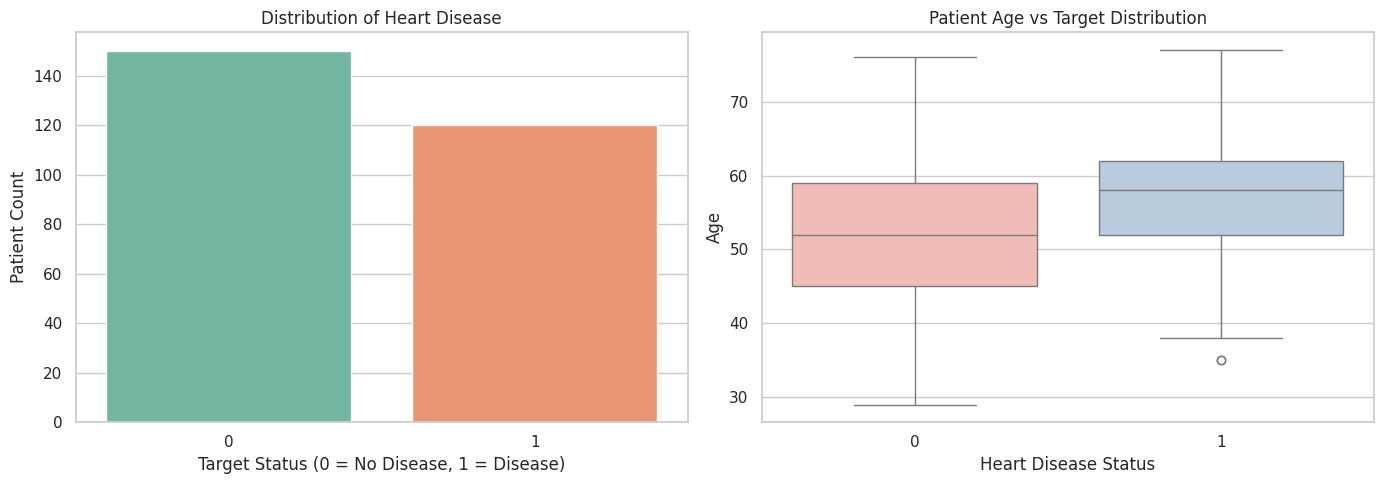

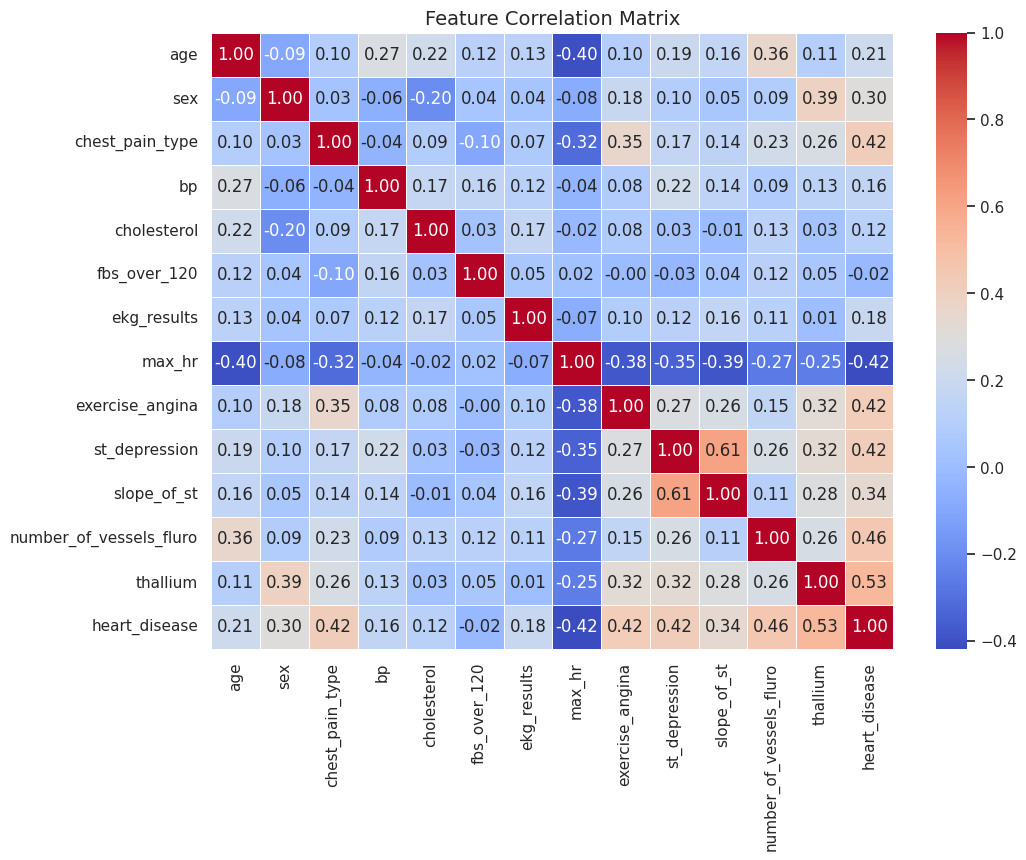


⚙️ Step 4: Splitting and scaling features...
Training Features Shape: (216, 13)
Testing Features Shape: (54, 13)

🤖 Step 5: Training and evaluating classification models...

==================== Logistic Regression Metrics ====================
Accuracy Score: 0.8519

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        30
           1       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54


==================== Decision Tree Metrics ====================
Accuracy Score: 0.7963

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.77      0.81        30
           1       0.74      0.83      0.78        24

    accuracy                           0.80        54
   macro avg       0.80      0.80

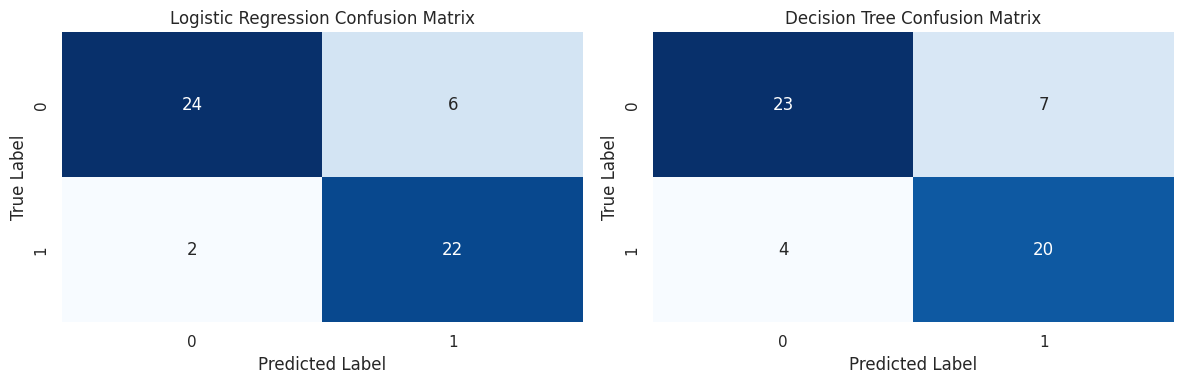


📈 Step 6: Plotting ROC Curves...


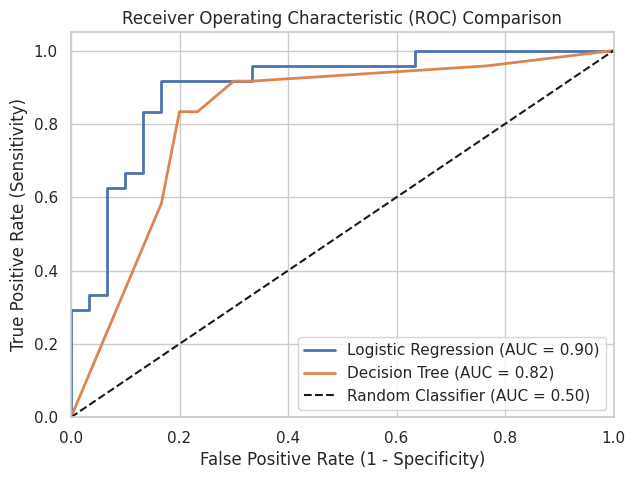


🎯 Step 7: Calculating feature importance rankings...


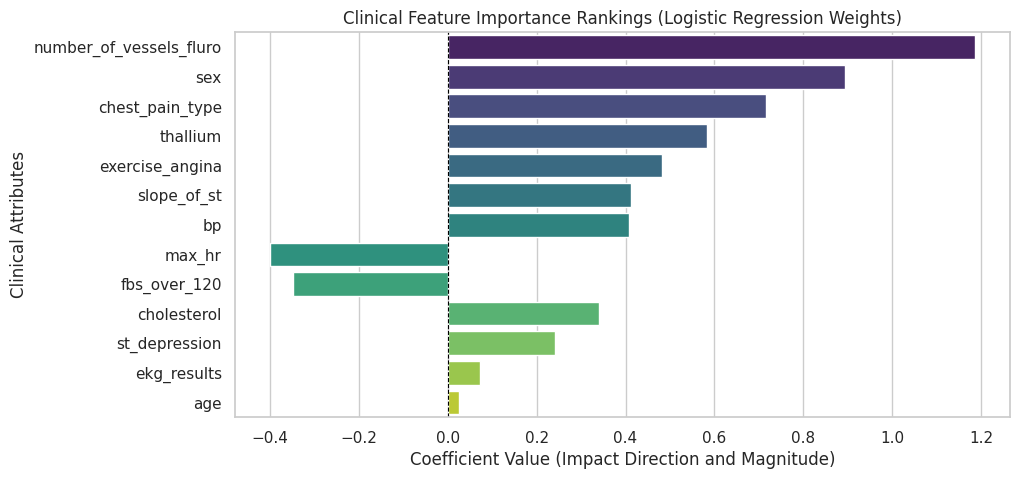


🚀 Pipeline complete! 


In [9]:
# ==============================================================================
# INTERNSHIP TASK: HEART DISEASE PREDICTION PIPELINE
# Objective: Clean data, perform EDA, train classifiers, and evaluate metrics.
# ==============================================================================

# ------------------------------------------------------------------------------
# Step 1: Import Required Libraries
# ------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# Set visualization aesthetics
sns.set_theme(style="whitegrid")
%matplotlib inline

print("📦 Step 1: Libraries imported successfully.")

# ------------------------------------------------------------------------------
# Step 2: Load and Clean Dataset from Specified Path
# ------------------------------------------------------------------------------
file_path = "/Heart_Disease_Prediction.csv"

try:
    df = pd.read_csv(file_path)
    print(f"\n📊 Step 2: Dataset loaded successfully from '{file_path}'.")
    print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns.")
except FileNotFoundError:
    print(f"\n❌ Error: File not found at '{file_path}'.")
    print("Please make sure the file is uploaded directly to Colab's root directory panel on the left.")
    raise

# Dynamic target handling to accommodate variations in file naming
possible_targets = ['target', 'Heart Disease', 'Heart_Disease', 'hd', 'condition', 'AHD']
target_col = None

for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    # Default fallback: pick the very last column if none of the above match
    target_col = df.columns[-1]
    print(f"⚠️ Target column not explicitly recognized. Defaulting to the last column: '{target_col}'")
else:
    print(f"🎯 Identified target classification column: '{target_col}'")

# Convert textual targets like ('Presence'/'Absence') or ('Yes'/'No') into binary 1s and 0s
if df[target_col].dtype == 'object':
    print(f"🔄 Text labels detected in '{target_col}'. Standardizing to numeric binary format (0 and 1)...")
    # Mapping positive class indicators to 1, rest to 0
    df[target_col] = df[target_col].apply(lambda x: 1 if str(x).strip().lower() in ['presence', 'yes', '1', 'heart_disease', 'disease'] else 0)

# Standardize feature column naming style for visualization purposes
df.columns = [col.strip().replace(' ', '_').lower() for col in df.columns]
target_col = target_col.strip().replace(' ', '_').lower()

# Data Cleaning: Handle missing values or placeholder strings like '?'
df = df.replace('?', np.nan)
missing_values = df.isnull().sum().sum()
if missing_values > 0:
    print(f"⚠️ Found {missing_values} missing or invalid values. Dropping rows with null values...")
    df = df.dropna()
else:
    print("✅ No missing values detected. Dataset is clean.")

# Cast all remaining feature columns to float/int to prevent matrix format errors
for col in df.columns:
    if col != target_col:
        df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna()

print("\n📋 Feature Summary Statistics:")
print(df.describe().T[['mean', 'std', 'min', 'max']])

# ------------------------------------------------------------------------------
# Step 3: Exploratory Data Analysis (EDA)
# ------------------------------------------------------------------------------
print("\n🎨 Step 3: Generating Exploratory Plots...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Target Variable Distribution
sns.countplot(x=target_col, data=df, ax=axes[0], palette='Set2', hue=target_col, legend=False)
axes[0].set_title('Distribution of Heart Disease')
axes[0].set_xlabel('Target Status (0 = No Disease, 1 = Disease)')
axes[0].set_ylabel('Patient Count')

# Plot 2: Age vs Target Distribution
sns.boxplot(x=target_col, y=df.columns[0], data=df, ax=axes[1], palette='Pastel1', hue=target_col, legend=False)
axes[1].set_title(f"Patient {df.columns[0].capitalize()} vs Target Distribution")
axes[1].set_xlabel('Heart Disease Status')
axes[1].set_ylabel(df.columns[0].capitalize())

plt.tight_layout()
plt.show()

# Heatmap: Correlation Matrix
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=True)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.show()

# ------------------------------------------------------------------------------
# Step 4: Data Preprocessing & Train-Test Split
# ------------------------------------------------------------------------------
print("\n⚙️ Step 4: Splitting and scaling features...")

# Split features and label
X = df.drop(columns=[target_col])
y = df[target_col]

# 80/20 train/test split with stratification to preserve target distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling (Crucial for optimal Logistic Regression convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

# ------------------------------------------------------------------------------
# Step 5: Model Training & Evaluation Pipeline
# ------------------------------------------------------------------------------
print("\n🤖 Step 5: Training and evaluating classification models...")

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42)
}

roc_data = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, (name, model) in enumerate(models.items()):
    # Fit model using scaled attributes
    model.fit(X_train_scaled, y_train)

    # Predict discrete outcomes and raw continuous probabilities
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    roc_data[name] = (y_test, y_prob)

    # Text Metrics Report
    print(f"\n==================== {name} Metrics ====================")
    print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix Heatmap
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[idx])
    axes[idx].set_title(f'{name} Confusion Matrix')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# Step 6: ROC Curve Comparison Plot
# ------------------------------------------------------------------------------
print("\n📈 Step 6: Plotting ROC Curves...")
plt.figure(figsize=(7, 5))

for name, (y_true, y_prob) in roc_data.items():
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Comparison')
plt.legend(loc="lower right")
plt.show()

# ------------------------------------------------------------------------------
# Step 7: Feature Importance Analysis (Logistic Regression Coefficients)
# ------------------------------------------------------------------------------
print("\n🎯 Step 7: Calculating feature importance rankings...")

log_reg_model = models["Logistic Regression"]
coefficients = log_reg_model.coef_[0]

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient Magnitude': coefficients
}).sort_values(by='Coefficient Magnitude', key=abs, ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Coefficient Magnitude', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Clinical Feature Importance Rankings (Logistic Regression Weights)')
plt.xlabel('Coefficient Value (Impact Direction and Magnitude)')
plt.ylabel('Clinical Attributes')
plt.show()

print("\n🚀 Pipeline complete! ")